In [ ]:
# ==============================================================================
# STAGE 2: STAGE 1 BINARY SCREENING MODEL TRAINING (IGCA-ViT)
# Framework: Two-Stage Cascade Triage (Screening Model)
# Dedicated Notebook Deployment Setup
# Author: Rajesh
# ==============================================================================

# ==============================================================================
# 0. GOOGLE DRIVE MOUNTING LAYER
# ==============================================================================
from google.colab import drive
import os

print("--- Mounting Google Drive ---")
drive.mount('/content/drive')

# Define your centralized workspace directory path
drive_path = '/content/drive/MyDrive/MTech_Thesis_Dataset'

# Verify path configuration before building layers
if not os.path.exists(drive_path):
    print(f"⚠️ Warning: Workspace folder not found at {drive_path}!")
    print("Creating the folder automatically. Ensure your 'proxy_doi_labels.csv' is placed inside it.")
    os.makedirs(drive_path, exist_ok=True)
else:
    print(f"✅ Centralized Thesis Directory Located Successfully at: {drive_path}")

--- Mounting Google Drive ---
Mounted at /content/drive
✅ Centralized Thesis Directory Located Successfully at: /content/drive/MyDrive/MTech_Thesis_Dataset


In [ ]:
# ==============================================================================
# 1. CORE DEPENDENCY ENTRANCE
# ==============================================================================
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ==============================================================================
# 2. DEFINING GLOBAL PATH VARIABLES
# ==============================================================================
CSV_PATH  = os.path.join(drive_path, 'proxy_doi_labels_multi_stage.csv')
SAVE_PATH = os.path.join(drive_path, 'Stage1_Screening_ViT_Best.pth')

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"❌ Critical Error: Could not find your proxy dataset sheet at: {CSV_PATH}. "
                            f"Please run your labeling script first or verify the file name!")

In [ ]:
# ==============================================================================
# 3. BIOLOGICALLY-GUIDED BINARY DATASET LOADER (STREAMLINED - NO AUGMENTATION)
# ==============================================================================
class Stage1BinaryDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

        # Masks resized to 224x224 to match ViT patch sequence space
        self.mask_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        cascade_label = row['Proxy_DOI_Class']  # Generated values: 0, 1, 2, 3

        # --- THE BINARY COMPRESSION LAYER ---
        # Map Class 0 (Healthy Control Base) to 0, and Classes 1, 2, 3 (All Cancer) to 1
        binary_label = 0 if cascade_label == 0 else 1

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # # Extract Masks (Using the 15x15 Elliptical Invasive Front Band Zone)
        # if str(mask_path).upper() == 'NONE' or pd.isna(mask_path):
        #     h, w = img.shape[:2]
        #     mask_bulk = np.zeros((h, w), dtype=np.uint8)
        #     mask_edge = np.zeros((h, w), dtype=np.uint8)
        # else:
        #     mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        #     _, mask_bulk = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

        #     kernel_size = 15
        #     kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        #     dilated_mask = cv2.dilate(mask_bulk, kernel, iterations=1)
        #     eroded_mask = cv2.erode(mask_bulk, kernel, iterations=1)
        #     mask_edge = cv2.subtract(dilated_mask, eroded_mask)

        # Extract Masks (Using the 15x15 Elliptical Invasive Front Band Zone)

        if str(mask_path).upper() == 'NONE' or pd.isna(mask_path):

            h, w = img.shape[:2]

            # Healthy tissue: keep entire image visible
            mask_bulk = np.ones((h, w), dtype=np.uint8) * 255

            # No invasive front exists
            mask_edge = np.zeros((h, w), dtype=np.uint8)

        else:

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            _, mask_bulk = cv2.threshold(
                mask,
                127,
                255,
                cv2.THRESH_BINARY
            )

            kernel_size = 15

            kernel = cv2.getStructuringElement(
                cv2.MORPH_ELLIPSE,
                (kernel_size, kernel_size)
            )

            dilated_mask = cv2.dilate(
                mask_bulk,
                kernel,
                iterations=1
            )

            eroded_mask = cv2.erode(
                mask_bulk,
                kernel,
                iterations=1
            )

            mask_edge = cv2.subtract(
                dilated_mask,
                eroded_mask
            )

        img_pil = Image.fromarray(img)
        mask_bulk_pil = Image.fromarray(mask_bulk)
        mask_edge_pil = Image.fromarray(mask_edge)

        # Apply Standard Resizing/Normalization to Image Only
        if self.transform:
            img_tensor = self.transform(img_pil)

        mask_bulk_tensor = self.mask_transform(mask_bulk_pil)
        mask_edge_tensor = self.mask_transform(mask_edge_pil)
        label_tensor = torch.tensor(binary_label, dtype=torch.long)

        return img_tensor, mask_bulk_tensor, mask_edge_tensor, label_tensor

In [ ]:
# ==============================================================================
# 4. NOVEL CASCADE SCREENING MODEL ARCHITECTURE (IGCA-ViT)
# ==============================================================================
class IGCABlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Binary_Classifier(nn.Module):
    def __init__(self, num_classes=2, embed_dim=768):
        super().__init__()
        # Pre-trained foundational Vision Transformer backbone (ImageNet-1K)
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x

    def forward(self, img, mask_bulk, mask_edge):
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        with torch.no_grad():
            bulk_tokens = self.extract_pretrained_tokens(bulk_img)
            edge_tokens = self.extract_pretrained_tokens(edge_img)

        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)
        return logits

In [ ]:
# ==============================================================================
# 5. INITIALIZING ENGINE PIPELINE EXECUTIONS
# ==============================================================================
if __name__ == "__main__":
    print("\n--- Step 2: Preparing Environment Device Settings ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Target Training Execution Engine running on: {device}")

    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    base_dataset = Stage1BinaryDataset(csv_file=CSV_PATH, transform=vit_transforms)
    total_size = len(base_dataset)
    train_size = int(0.8 * total_size)
    val_size = total_size - train_size

    generator = torch.Generator().manual_seed(42)
    # train_dataset, val_dataset = random_split(base_dataset, [train_size, val_size], generator=generator)
    # ==============================================================================
    # FIXED: PATIENT-WISE GROUP SPLITTING (PREVENTS DATA LEAKAGE)
    # ==============================================================================
    print("\n--- Running Patient-Wise Group Splitting ---")

    # 1. Read the full dataset sheet to find unique patient IDs
    full_df = pd.read_csv(CSV_PATH)
    unique_patients = full_df['patient_id'].unique()

    # Set seed for reproducibility
    np.random.seed(42)
    np.random.shuffle(unique_patients)

    # Allocate 80% of unique PATIENTS to train, 20% to validation
    split_idx = int(0.8 * len(unique_patients))
    train_patients = unique_patients[:split_idx]
    val_patients   = unique_patients[split_idx:]

    print(f"Total Unique Patients: {len(unique_patients)}")
    print(f"Allocated {len(train_patients)} patients to Train and {len(val_patients)} to Validation.")

    # 2. Build explicit, isolated data splits based on patient boundaries
    train_df = full_df[full_df['patient_id'].isin(train_patients)].copy()
    val_df   = full_df[full_df['patient_id'].isin(val_patients)].copy()

    # Write temporary CSVs so our dataset loader can ingest them directly
    train_csv_tmp = os.path.join(drive_path, 'train_split_tmp.csv')
    val_csv_tmp   = os.path.join(drive_path, 'val_split_tmp.csv')

    train_df.to_csv(train_csv_tmp, index=False)
    val_df.to_csv(val_csv_tmp, index=False)

    # 3. Instantiate the isolated splits
    train_dataset = Stage1BinaryDataset(csv_file=train_csv_tmp, transform=vit_transforms)
    val_dataset   = Stage1BinaryDataset(csv_file=val_csv_tmp, transform=vit_transforms)

    # Track structural sample lengths
    train_size = len(train_dataset)
    val_size   = len(val_dataset)
    print(f"Patient-Wise Totals: {train_size} Training Patches | {val_size} Validation Patches")

    # 4. Oversampling configurations applied strictly to Train split rows
    train_labels = [0 if train_df.iloc[idx]['Proxy_DOI_Class'] == 0 else 1 for idx in range(train_size)]
    class_counts = np.bincount(train_labels)

    class_weights_dict = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
    sample_weights = [class_weights_dict[label] for label in train_labels]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    # Configure loaders
    train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
    val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

    # Remember to clean up the temporary files at the end of the script execution if desired:
    # os.remove(train_csv_tmp); os.remove(val_csv_tmp)

    # Dynamic Loader Configuration to address Class Imbalance via oversampling
    # train_labels = [0 if train_dataset.dataset.data.iloc[idx]['Proxy_DOI_Class'] == 0 else 1 for idx in train_dataset.indices]

    # class_counts = np.bincount(train_labels)
    # class_weights_dict = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
    # sample_weights = [class_weights_dict[label] for label in train_labels]

    # sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    # ==============================================================================
    # FIXED: DIRECT DATAFRAME LOOKUP FOR OVER-SAMPLING (FIXES ATTRIBUTEERROR)
    # ==============================================================================
    # Read the labels directly from our isolated training dataframe slice
    train_labels = [0 if train_df.iloc[idx]['Proxy_DOI_Class'] == 0 else 1 for idx in range(train_size)]

    class_counts = np.bincount(train_labels)
    print(f"Calculated Binary Class Counts for Training -> Healthy: {class_counts[0]}, Malignant: {class_counts[1]}")

    class_weights_dict = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
    sample_weights = [class_weights_dict[label] for label in train_labels]

    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

    print(f"Data Core Configured: {train_size} Training Patches | {val_size} Validation Patches")

    # Architecture Initialization
    model = IGCA_ViT_Binary_Classifier(num_classes=2).to(device)

    # Injected weighted loss constraints
    loss_weights = torch.tensor([1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=loss_weights)

    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-3)

    EPOCHS = 20
    best_val_loss = float('inf')

    print(f"\n--- Starting Stage 1 Screening Model Training Loop ---")
    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct = 0.0, 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")

        for imgs, b_masks, e_masks, labels in train_loop:
            imgs, b_masks, e_masks, labels = imgs.to(device), b_masks.to(device), e_masks.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs, b_masks, e_masks)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / train_size

        # Validation phase loops
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]")
            for imgs, b_masks, e_masks, labels in val_loop:
                imgs, b_masks, e_masks, labels = imgs.to(device), b_masks.to(device), e_masks.to(device), labels.to(device)

                outputs = model(imgs, b_masks, e_masks)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data).item()

        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_size

        print(f"\nEnd of Epoch {epoch+1}")
        print(f"TRAIN LOG -> Loss: {avg_train_loss:.4f} | Accuracy: {avg_train_acc:.4f}")
        print(f"VALID LOG -> Loss: {avg_val_loss:.4f} | Accuracy: {avg_val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), SAVE_PATH)
            print("🌟 Screening Model Validation Loss Improved! Saving parameters to Drive.")
        else:
            print("Validation metrics did not improve.")
        print("-" * 60)


--- Step 2: Preparing Environment Device Settings ---
Target Training Execution Engine running on: cuda

--- Running Patient-Wise Group Splitting ---
Total Unique Patients: 7
Allocated 5 patients to Train and 2 to Validation.
Patient-Wise Totals: 600 Training Patches | 240 Validation Patches
Calculated Binary Class Counts for Training -> Healthy: 295, Malignant: 305
Data Core Configured: 600 Training Patches | 240 Validation Patches

--- Starting Stage 1 Screening Model Training Loop ---


Epoch 1/20 [Valid]: 100%|██████████| 15/15 [00:11<00:00,  1.36it/s]



End of Epoch 1
TRAIN LOG -> Loss: 0.0537 | Accuracy: 0.9733
VALID LOG -> Loss: 0.1480 | Accuracy: 0.9792
🌟 Screening Model Validation Loss Improved! Saving parameters to Drive.
------------------------------------------------------------


Epoch 2/20 [Valid]: 100%|██████████| 15/15 [00:10<00:00,  1.40it/s]



End of Epoch 2
TRAIN LOG -> Loss: 0.0238 | Accuracy: 0.9950
VALID LOG -> Loss: 0.0090 | Accuracy: 0.9958
🌟 Screening Model Validation Loss Improved! Saving parameters to Drive.
------------------------------------------------------------


...


End of Epoch 18
TRAIN LOG -> Loss: 0.0000 | Accuracy: 1.0000
VALID LOG -> Loss: 0.0098 | Accuracy: 0.9958
Validation metrics did not improve.
------------------------------------------------------------


Epoch 19/20 [Valid]: 100%|██████████| 15/15 [00:10<00:00,  1.43it/s]



End of Epoch 19
TRAIN LOG -> Loss: 0.0000 | Accuracy: 1.0000
VALID LOG -> Loss: 0.0097 | Accuracy: 0.9958
Validation metrics did not improve.
------------------------------------------------------------


Epoch 20/20 [Valid]: 100%|██████████| 15/15 [00:11<00:00,  1.32it/s]


End of Epoch 20
TRAIN LOG -> Loss: 0.0000 | Accuracy: 1.0000
VALID LOG -> Loss: 0.0098 | Accuracy: 0.9958
Validation metrics did not improve.
------------------------------------------------------------


--- Mounting Google Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Evaluation Engine running on: cuda

--- Identifying Validation Set Patient Cohorts ---
Validation Patients Isolated: ['1009014' '1009023']
Successfully loaded 240 unseen patches for evaluation.
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 188MB/s]


Loading weights state dictionary from: /content/drive/MyDrive/MTech_Thesis_Dataset/Stage1_Screening_ViT_Best.pth


Running Inference: 100%|██████████| 15/15 [03:44<00:00, 14.98s/it]



      STAGE 1 BINARY CLASSIFICATION REPORT      
                     precision    recall  f1-score   support

Healthy Base Tissue       0.99      1.00      1.00       155
 Malignant Positive       1.00      0.99      0.99        85

           accuracy                           1.00       240
          macro avg       1.00      0.99      1.00       240
       weighted avg       1.00      1.00      1.00       240


--- Generating Screening Confusion Matrix ---


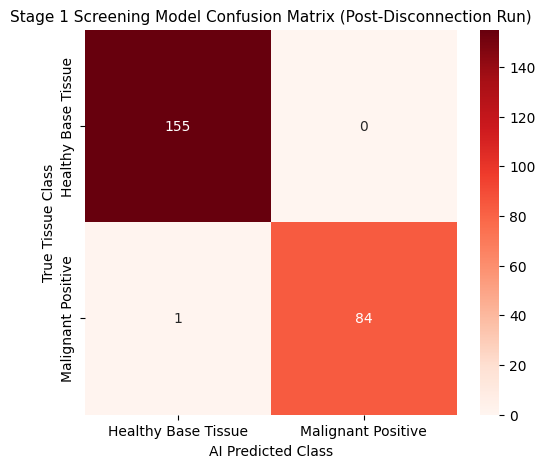

In [ ]:
# ==============================================================================
# STAGE 2: STAGE 1 BINARY SCREENING MODEL INDEPENDENT EVALUATION RUNTIME
# Framework: Two-Stage Cascade Triage (Screening Model) - NO DATA LEAKAGE
# Author: Rajesh
# ==============================================================================

# ==============================================================================
# 0. GOOGLE DRIVE MOUNTING LAYER
# ==============================================================================
from google.colab import drive
import os

print("--- Mounting Google Drive ---")
drive.mount('/content/drive')

# Define your centralized workspace directory path
drive_path = '/content/drive/MyDrive/MTech_Thesis_Dataset'
CSV_PATH  = os.path.join(drive_path, 'proxy_doi_labels_multi_stage.csv')
SAVE_PATH = os.path.join(drive_path, 'Stage1_Screening_ViT_Best.pth')

if not os.path.exists(SAVE_PATH):
    raise FileNotFoundError(f"❌ Critical Error: Saved weights not found at {SAVE_PATH}. Please verify your file path!")

# ==============================================================================
# 1. CORE DEPENDENCY ENTRANCE
# ==============================================================================
import cv2
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# ==============================================================================
# 2. DATASET LOADER DEFINITION
# ==============================================================================
class Stage1BinaryDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform
        self.mask_transform = transforms.Compose([
            transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']
        mask_path = row['mask_path']
        cascade_label = row['Proxy_DOI_Class']

        # Binary Triage Classification Mapping
        binary_label = 0 if cascade_label == 0 else 1

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if str(mask_path).upper() == 'NONE' or pd.isna(mask_path):
            h, w = img.shape[:2]
            mask_bulk = np.ones((h, w), dtype=np.uint8)
            mask_edge = np.zeros((h, w), dtype=np.uint8)
        else:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            _, mask_bulk = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

            kernel_size = 15
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
            dilated_mask = cv2.dilate(mask_bulk, kernel, iterations=1)
            eroded_mask = cv2.erode(mask_bulk, kernel, iterations=1)
            mask_edge = cv2.subtract(dilated_mask, eroded_mask)

        img_pil = Image.fromarray(img)
        mask_bulk_pil = Image.fromarray(mask_bulk)
        mask_edge_pil = Image.fromarray(mask_edge)

        if self.transform:
            img_tensor = self.transform(img_pil)

        mask_bulk_tensor = self.mask_transform(mask_bulk_pil)
        mask_edge_tensor = self.mask_transform(mask_edge_pil)
        label_tensor = torch.tensor(binary_label, dtype=torch.long)

        return img_tensor, mask_bulk_tensor, mask_edge_tensor, label_tensor

# ==============================================================================
# 3. NOVEL CASCADE SCREENING MODEL ARCHITECTURE (IGCA-ViT)
# ==============================================================================
class IGCABlock(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8):
        super().__init__()
        self.norm_edge = nn.LayerNorm(embed_dim)
        self.norm_bulk = nn.LayerNorm(embed_dim)
        self.cross_attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.ffn = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )

    def forward(self, edge_tokens, bulk_tokens):
        q = self.norm_edge(edge_tokens)
        k = self.norm_bulk(bulk_tokens)
        v = k
        attn_output, _ = self.cross_attn(query=q, key=k, value=v)
        x = edge_tokens + attn_output
        x = x + self.ffn(x)
        return x

class IGCA_ViT_Binary_Classifier(nn.Module):
    def __init__(self, num_classes=2, embed_dim=768):
        super().__init__()
        self.backbone = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.igca_layer = IGCABlock(embed_dim=embed_dim, num_heads=8)
        self.norm = nn.LayerNorm(embed_dim)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def extract_pretrained_tokens(self, x):
        x = self.backbone._process_input(x)
        n = x.shape[0]
        batch_class_token = self.backbone.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = self.backbone.encoder(x)
        return x

    def forward(self, img, mask_bulk, mask_edge):
        bulk_img = img * mask_bulk
        edge_img = img * mask_edge

        with torch.no_grad():
            bulk_tokens = self.extract_pretrained_tokens(bulk_img)
            edge_tokens = self.extract_pretrained_tokens(edge_img)

        fused_tokens = self.igca_layer(edge_tokens=edge_tokens, bulk_tokens=bulk_tokens)
        global_feature = fused_tokens[:, 1:, :].mean(dim=1)

        global_feature = self.norm(global_feature)
        logits = self.classifier(global_feature)
        return logits

# ==============================================================================
# 4. RUNTIME EVALUATION PIPELINE
# ==============================================================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Evaluation Engine running on: {device}")

    # Reconstruct the exact same patient-wise group split boundaries
    print("\n--- Identifying Validation Set Patient Cohorts ---")
    full_df = pd.read_csv(CSV_PATH)
    unique_patients = full_df['patient_id'].unique()

    np.random.seed(42)  # MUST BE 42 to isolate the identical 2 validation patients
    np.random.shuffle(unique_patients)

    split_idx = int(0.8 * len(unique_patients))
    val_patients = unique_patients[split_idx:]
    print(f"Validation Patients Isolated: {val_patients}")

    # Build the specific validation dataset split
    val_df = full_df[full_df['patient_id'].isin(val_patients)].copy()
    val_csv_tmp = os.path.join(drive_path, 'val_split_eval_tmp.csv')
    val_df.to_csv(val_csv_tmp, index=False)

    vit_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    val_dataset = Stage1BinaryDataset(csv_file=val_csv_tmp, transform=vit_transforms)
    val_loader  = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
    print(f"Successfully loaded {len(val_dataset)} unseen patches for evaluation.")

    # Instantiate model and inject state weights saved in Drive
    model = IGCA_ViT_Binary_Classifier(num_classes=2).to(device)
    print(f"Loading weights state dictionary from: {SAVE_PATH}")
    model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
    model.eval()

    # Inference Loop Execution
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, b_masks, e_masks, labels in tqdm(val_loader, desc="Running Inference"):
            imgs, b_masks, e_masks = imgs.to(device), b_masks.to(device), e_masks.to(device)
            outputs = model(imgs, b_masks, e_masks)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # --- Print Performance Reports ---
    print("\n" + "="*50)
    print("      STAGE 1 BINARY CLASSIFICATION REPORT      ")
    print("="*50)
    target_names = ['Healthy Base Tissue', 'Malignant Positive']
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # --- Generate Confusion Matrix ---
    print("\n--- Generating Screening Confusion Matrix ---")
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
    plt.title('Stage 1 Screening Model Confusion Matrix (Post-Disconnection Run)', fontsize=11)
    plt.ylabel('True Tissue Class', fontsize=10)
    plt.xlabel('AI Predicted Class', fontsize=10)
    plt.show()

    # Clean up temporary split file
    if os.path.exists(val_csv_tmp):
        os.remove(val_csv_tmp)